# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,d_I,K_I,b_I,K_H,N_0,S_0,I_0,d_S,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.15,10000.0,1.500000e-07,10000.0,100.0,10000000.0,10000.0,0.01,9.602980e+06,0.000000,0.000000,0.000000,0.000000,0.0,6.96,20.00,13.04,2.834876,1.708950,0.000000,0.015024,inf,4.80149,0.000000,0.000000
1,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.15,10000.0,1.500000e-07,10000.0,100.0,10000000.0,10000.0,0.01,9.602980e+06,0.000000,0.000000,0.000000,0.000000,0.0,6.96,20.00,13.04,2.834876,1.708950,0.000000,0.015024,inf,4.80149,0.000000,0.000000
2,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.15,10000.0,1.500000e-07,10000.0,100.0,10000000.0,10000.0,0.01,9.602980e+06,0.000000,0.000000,0.000000,0.000000,0.0,6.96,20.00,13.04,2.834876,1.708950,0.000000,0.015024,inf,4.80149,0.000000,0.000000
3,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.15,10000.0,1.500000e-07,10000.0,100.0,10000000.0,10000.0,0.01,9.602980e+06,0.000000,0.000000,0.000000,0.000000,0.0,6.96,20.00,13.04,2.834876,1.708950,0.000000,0.015024,inf,4.80149,0.000000,0.000000
4,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.15,10000.0,1.500000e-07,10000.0,100.0,10000000.0,10000.0,0.01,9.602980e+06,0.000000,0.000000,0.000000,0.000000,0.0,6.96,20.00,13.04,2.834876,1.708950,0.000000,0.015024,inf,4.80149,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310620,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,0.01,10000000.0,1.000000e-01,10000.0,1000.0,10000000.0,1000000.0,0.01,4.921953e+03,4181.976791,1.097049,0.162042,0.018344,0.0,20.00,0.56,-18.82,0.184217,1.225797,0.081455,0.603817,6.000001,0.00000,-0.002461,0.002091
310621,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,0.01,10000000.0,1.000000e-01,10000.0,1000.0,10000000.0,1000000.0,0.01,3.541137e+03,3087.714085,0.982045,0.156351,0.013662,0.0,20.00,0.57,-19.09,0.184363,1.226036,0.068160,0.603564,6.000001,0.00000,-0.001771,0.001544
310622,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.01,10000000.0,1.000000e-01,10000.0,1000.0,10000000.0,1000000.0,0.01,1.689312e+03,1521.053371,0.707996,0.168902,0.006993,0.0,20.00,20.00,-19.18,0.184570,1.226369,0.040681,0.603195,6.000001,0.00000,-0.000845,0.000761
310623,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,0.01,10000000.0,1.000000e-01,10000.0,1000.0,10000000.0,1000000.0,0.01,1.249474e+03,1136.322146,0.599119,0.149343,0.005045,0.0,20.00,20.00,-19.22,0.184621,1.226450,0.034825,0.603103,6.000001,0.00000,-0.000625,0.000568


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

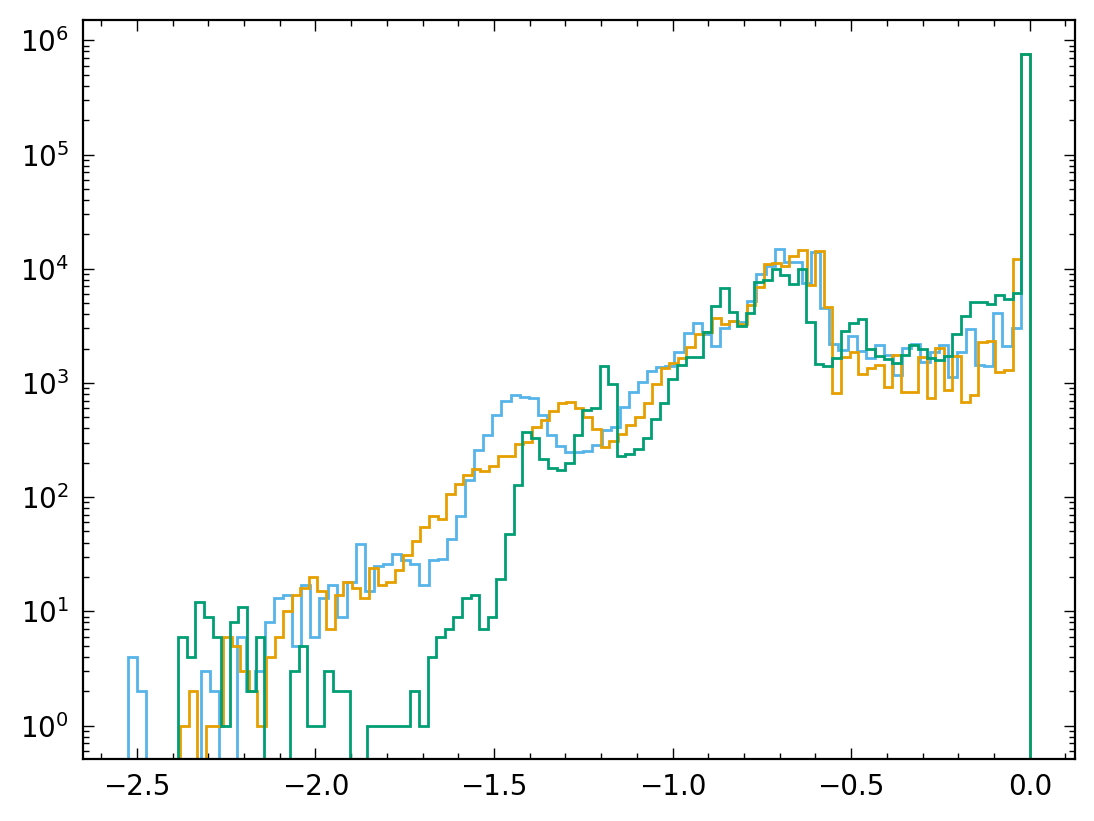

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-1.244391e+17,0.799531,1.226685,2.525270
1,-6.000001e+00,1.732615,1.226685,2.523195
2,1.226589e-01,0.000434,0.123443,2.134444
3,1.362877e-01,0.000866,0.123443,2.134328
4,1.363118e-01,0.002352,0.671071,2.134215
...,...,...,...,...
109,3.069396e+00,2.271650,1.885279,2.261455
110,3.630744e+00,2.404115,1.850839,2.383448
111,4.559923e+00,2.535507,1.708950,2.506482
112,6.000001e+00,0.184770,1.226685,2.536809


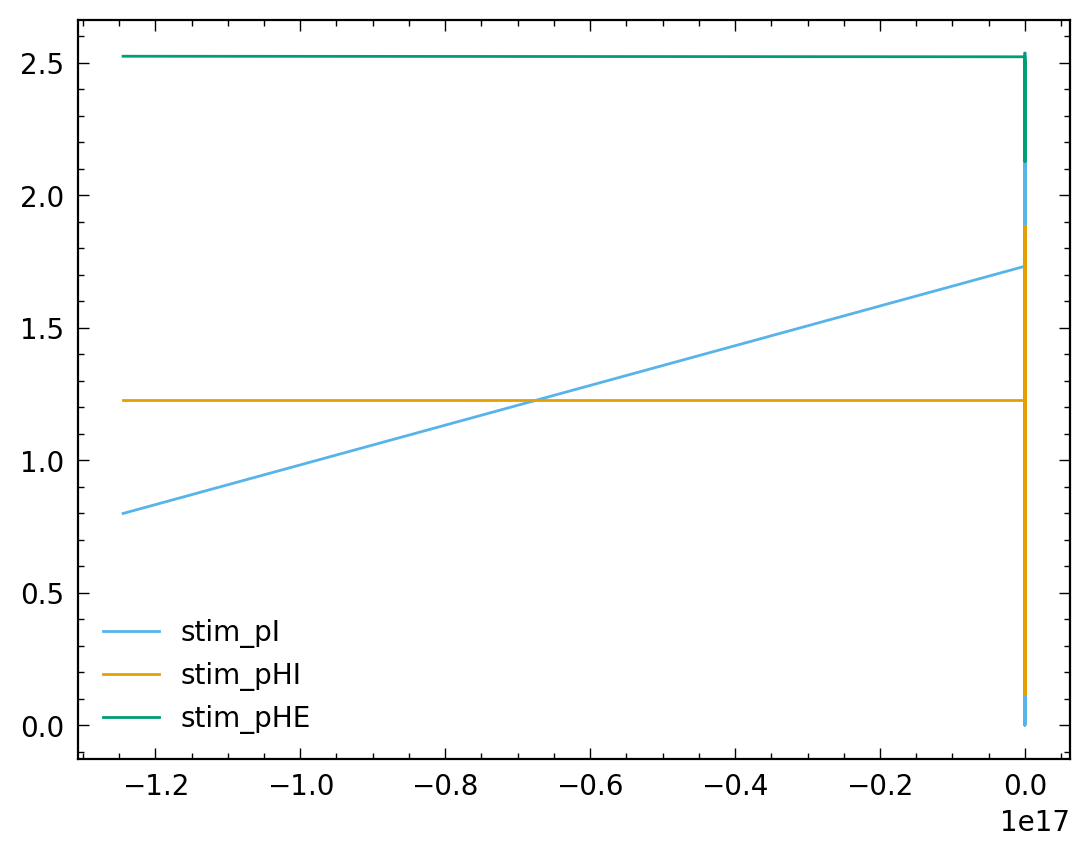

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 11
fevals: 11
fevals: 8
fevals: 10
fevals: 18
fevals: 16
fevals: 37
fevals: 19
fevals: 16
fevals: 14
fevals: 15
fevals: 26
fevals: 16
fevals: 14
fevals: 15
fevals: 26


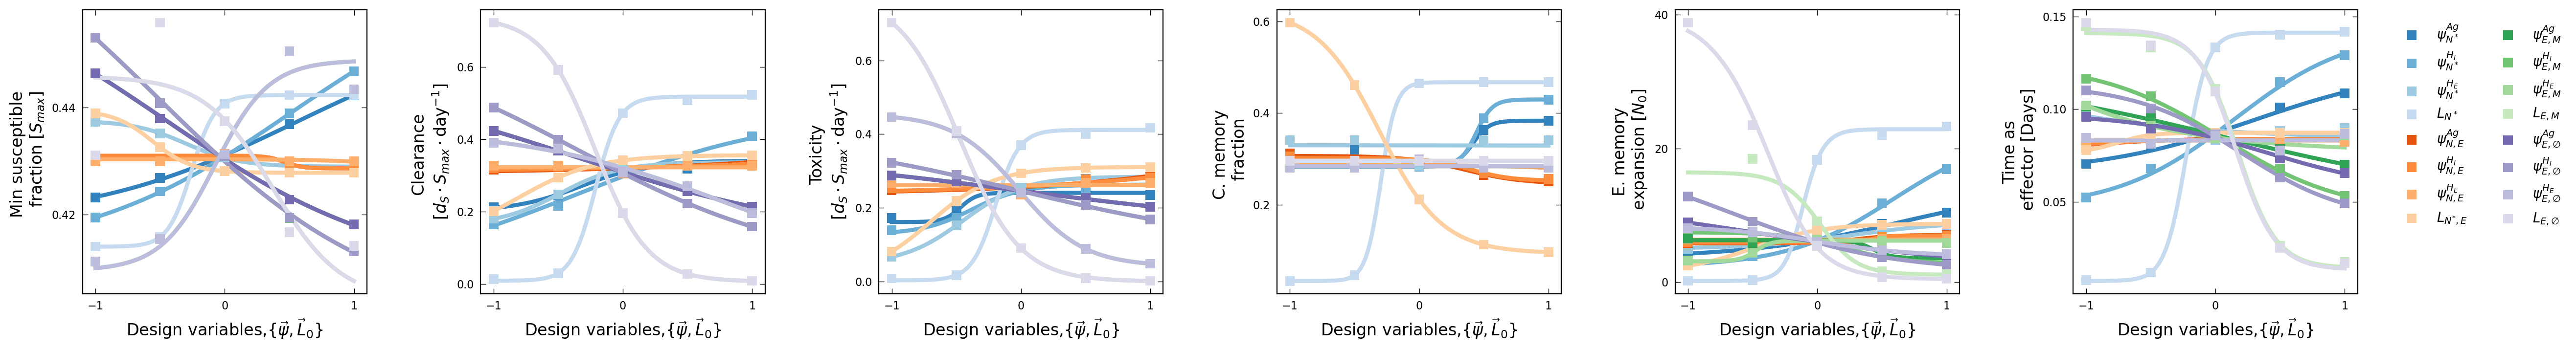

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*y_max if y_max > 0 else y_std*0.01, np.maximum(y_min, 0) + y_std*0.01, 2*L0_max, 2*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 131
variables = reg
tol = 1e-6

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[np.minimum(2*y_max, y_max/2) + y_std*tol, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([np.minimum(2*y_max, y_max/2), np.minimum(0.0, y_min)] + len(variables)*[-4.0*L0_max] + num_modules*[-4.0*L0_max], 
                                     [np.log10(2) if perf == "log_T_pEcyteM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[4.0*L0_max] + num_modules*[4.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [21]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.d_I <= 0.15)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
727,2.450831e-07,-2.216162,-0.331282,-0.193219,-0.055371,-0.410477,-2.830018,-0.061377,-0.031548,-0.113464,0.342723,0.200079,0.078235,0.428324,0.347458,0.195208,0.074247,0.429010,5.015361,11.129047,4.494822,4.493663,0.001648,0.483402,0.014688,0.013812,0.013085,0.017019,3.347766,0.129793,0.128851,0.073000,0.010826,0.009124,0.007924,0.011427,0.010875,0.009049,0.007872,0.011416,0.233777,6.727881,0.217255,0.217184,0.01,100000.0,0.1,10000.0,10.0,10000000.0,1000000.0,-0.097426,0.0,-2.216162,-0.000011,1.0,0.222382,0.245083,0.0,1.666859,1.184507,0.243569,-6.000001e+00
733,3.121707e-07,-2.379096,-0.393226,-0.206277,-0.075615,-0.347197,-2.967302,0.083359,-0.007128,0.047978,0.357221,0.195840,0.063818,0.353386,0.357160,0.194987,0.059940,0.354046,4.306911,11.049714,4.206337,4.205781,0.002616,0.528917,0.013649,0.011106,0.009757,0.012291,3.581203,0.121186,0.119020,0.060943,0.012652,0.010435,0.009108,0.011852,0.012635,0.010412,0.009076,0.011850,0.226312,7.188558,0.225819,0.225843,0.01,100000.0,0.1,10000.0,100.0,10000000.0,1000000.0,-0.134333,0.0,-2.379096,-0.000192,1.0,0.287375,0.312171,0.0,1.632884,1.163768,0.336879,-6.000001e+00
739,2.712437e-07,-2.256508,-0.354980,-0.180812,-0.065340,-0.346070,0.531946,0.122939,0.017339,-0.084436,0.318346,0.173651,0.074554,0.362763,0.317679,0.174457,0.074479,0.362794,4.263183,11.910772,4.241996,4.242146,0.003824,0.481595,0.011944,0.009860,0.008890,0.011265,71.454704,28.102258,25.305246,15.925713,0.011131,0.009487,0.008661,0.011198,0.011124,0.009497,0.008662,0.011200,0.218655,212.902141,0.218536,0.218541,0.01,100000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,-0.127393,0.0,-2.256508,-0.001934,1.0,0.246657,0.271244,0.0,1.610829,1.147412,0.459287,-6.000001e+00
745,2.206976e-07,-2.124118,-0.138289,-0.302879,-0.074982,-0.448151,-0.021072,-2.127154,0.041806,-0.398897,0.118719,0.271078,0.144571,0.481202,0.116419,0.273653,0.141540,0.480479,5.291572,11.507714,4.652052,4.651691,0.001345,0.459144,0.014834,0.015539,0.014580,0.019624,0.315386,3.306973,0.316468,0.408080,0.007889,0.009251,0.008093,0.011429,0.007884,0.009279,0.008079,0.011428,0.236716,6.958671,0.216805,0.216886,0.01,1000000.0,0.1,10000.0,10.0,10000000.0,1000000.0,-0.086082,0.0,-2.124118,-0.000010,1.0,0.197757,0.220698,0.0,0.754675,1.188807,0.222445,-1.244391e+17
751,3.191768e-07,-2.316057,-0.147147,-0.340744,-0.121683,-0.375971,-0.077886,-2.989613,0.001366,-0.020430,0.136781,0.302626,0.090052,0.384099,0.137284,0.303991,0.089274,0.383889,4.348970,10.894443,4.184053,4.184363,0.002526,0.473484,0.010846,0.012792,0.010641,0.013092,0.105835,3.204175,0.104175,0.052313,0.009648,0.011403,0.009286,0.012018,0.009653,0.011423,0.009281,0.012017,0.212790,6.429884,0.210550,0.210520,0.01,1000000.0,0.1,10000.0,100.0,10000000.0,1000000.0,-0.137313,0.0,-2.316057,-0.000162,1.0,0.292096,0.319177,0.0,0.727266,1.166688,0.325611,-1.244391e+17
757,2.866679e-07,-2.525256,-0.136215,-0.293073,-0.112411,-0.370239,-0.023245,0.045445,0.006257,0.089999,0.125431,0.263882,0.098409,0.379501,0.125159,0.263683,0.098436,0.379511,4.413887,11.440735,4.320349,4.319517,0.017869,0.578821,0.009816,0.011230,0.009647,0.012007,27.686335,36.031757,24.356355,57.464249,0.009047,0.010298,0.008863,0.011392,0.009041,0.010292,0.008859,0.011388,0.237036,673.167722,0.235808,0.235802,0.01,1000000.0,0.1,1

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

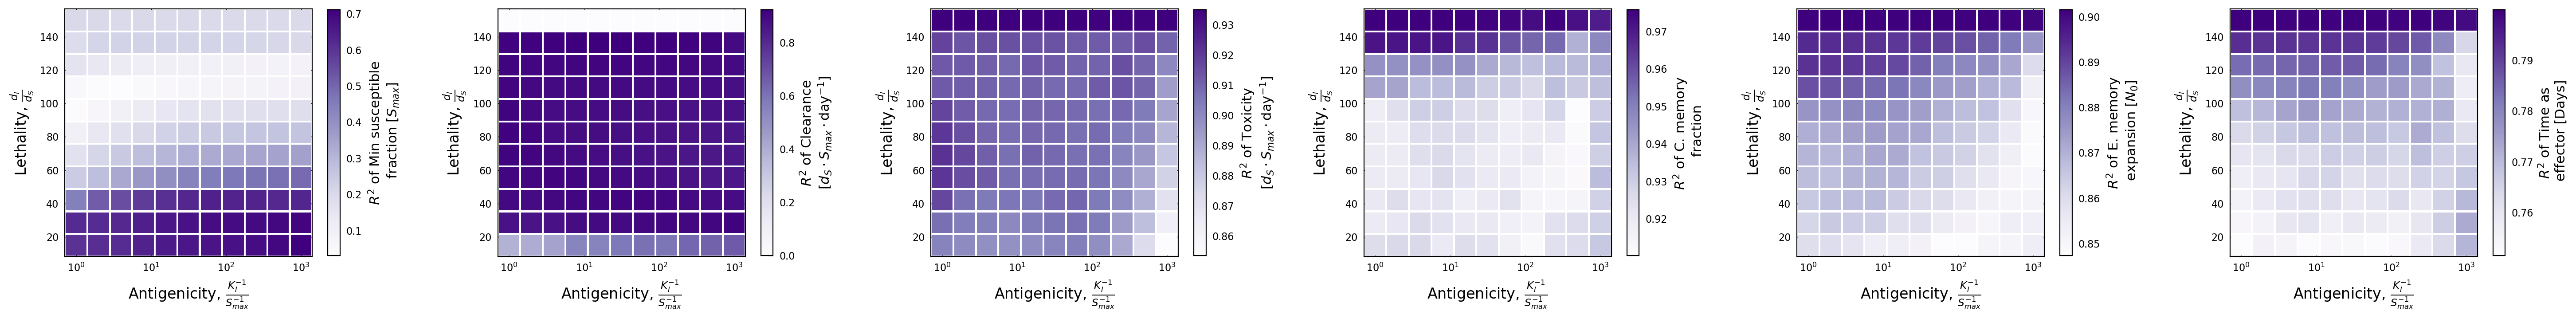

In [11]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_0)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

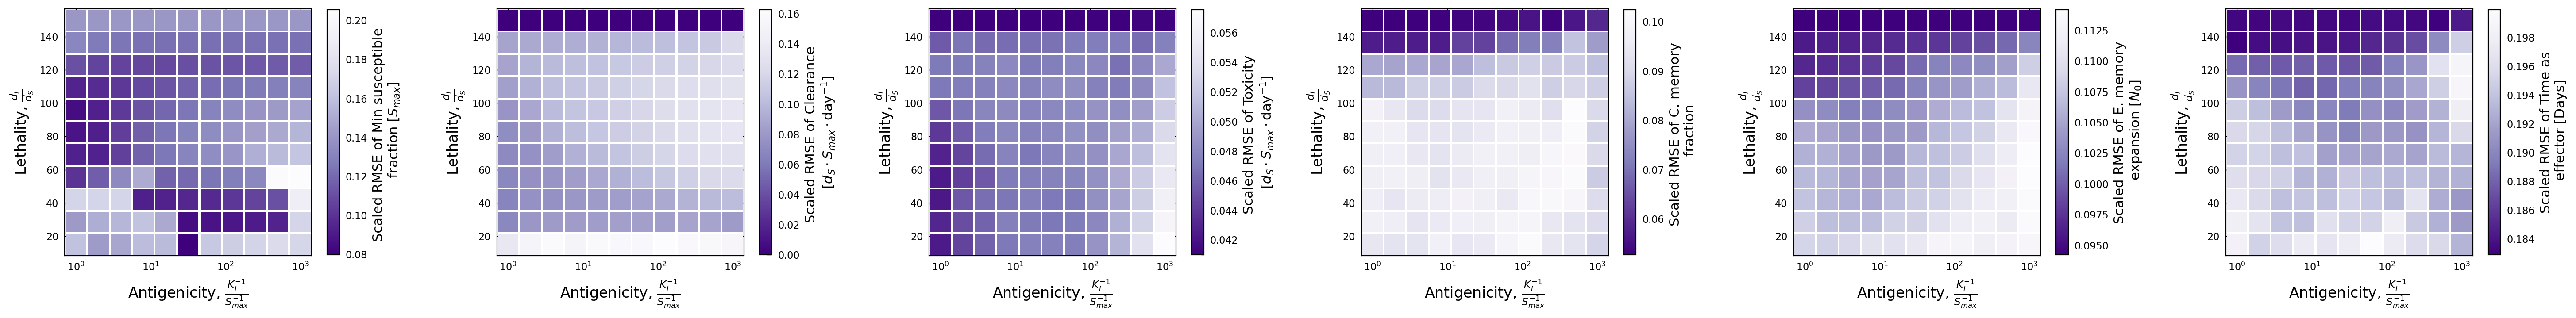

In [12]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_0)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

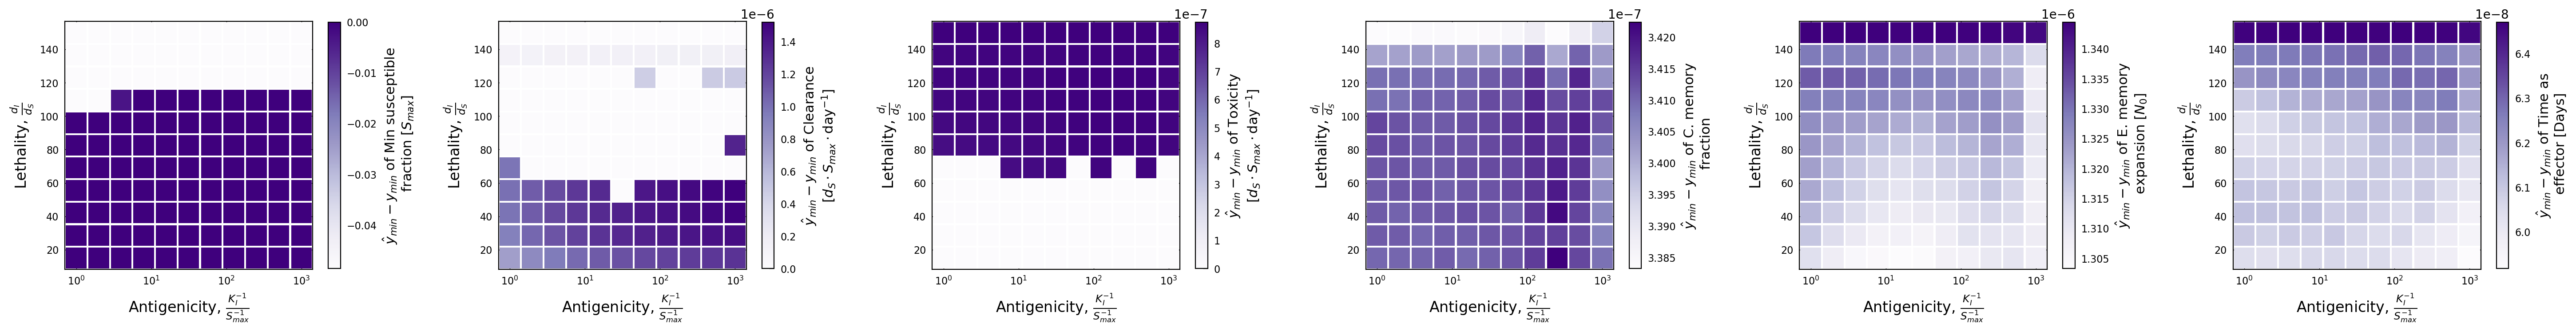

In [13]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_0)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

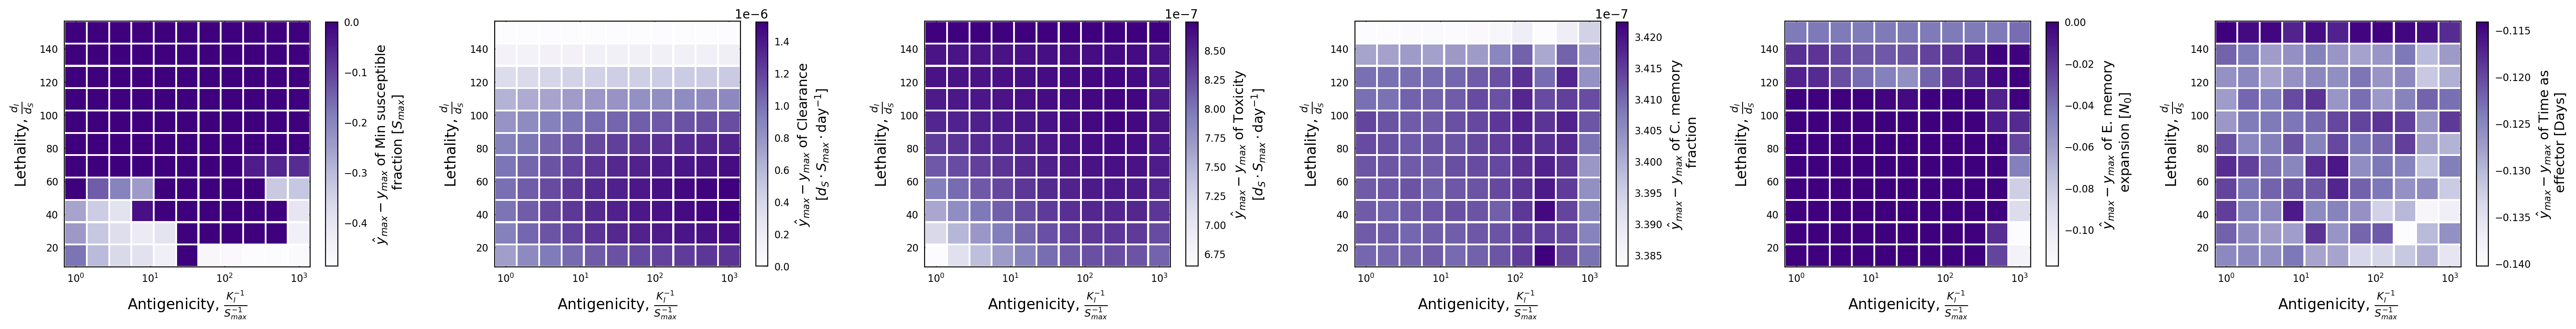

In [14]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_0)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

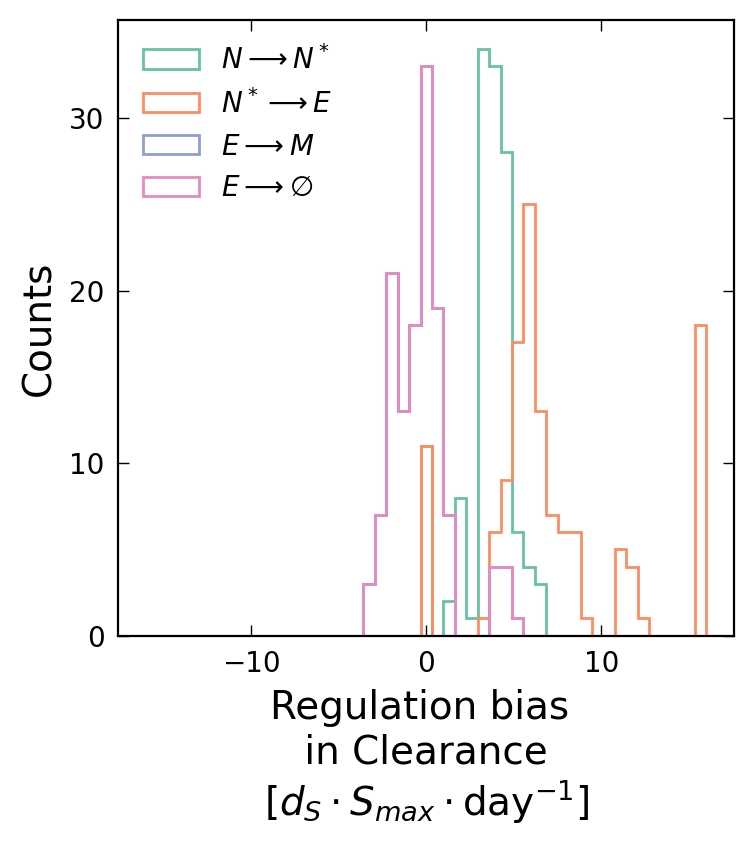

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-4*L0_max, 4*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

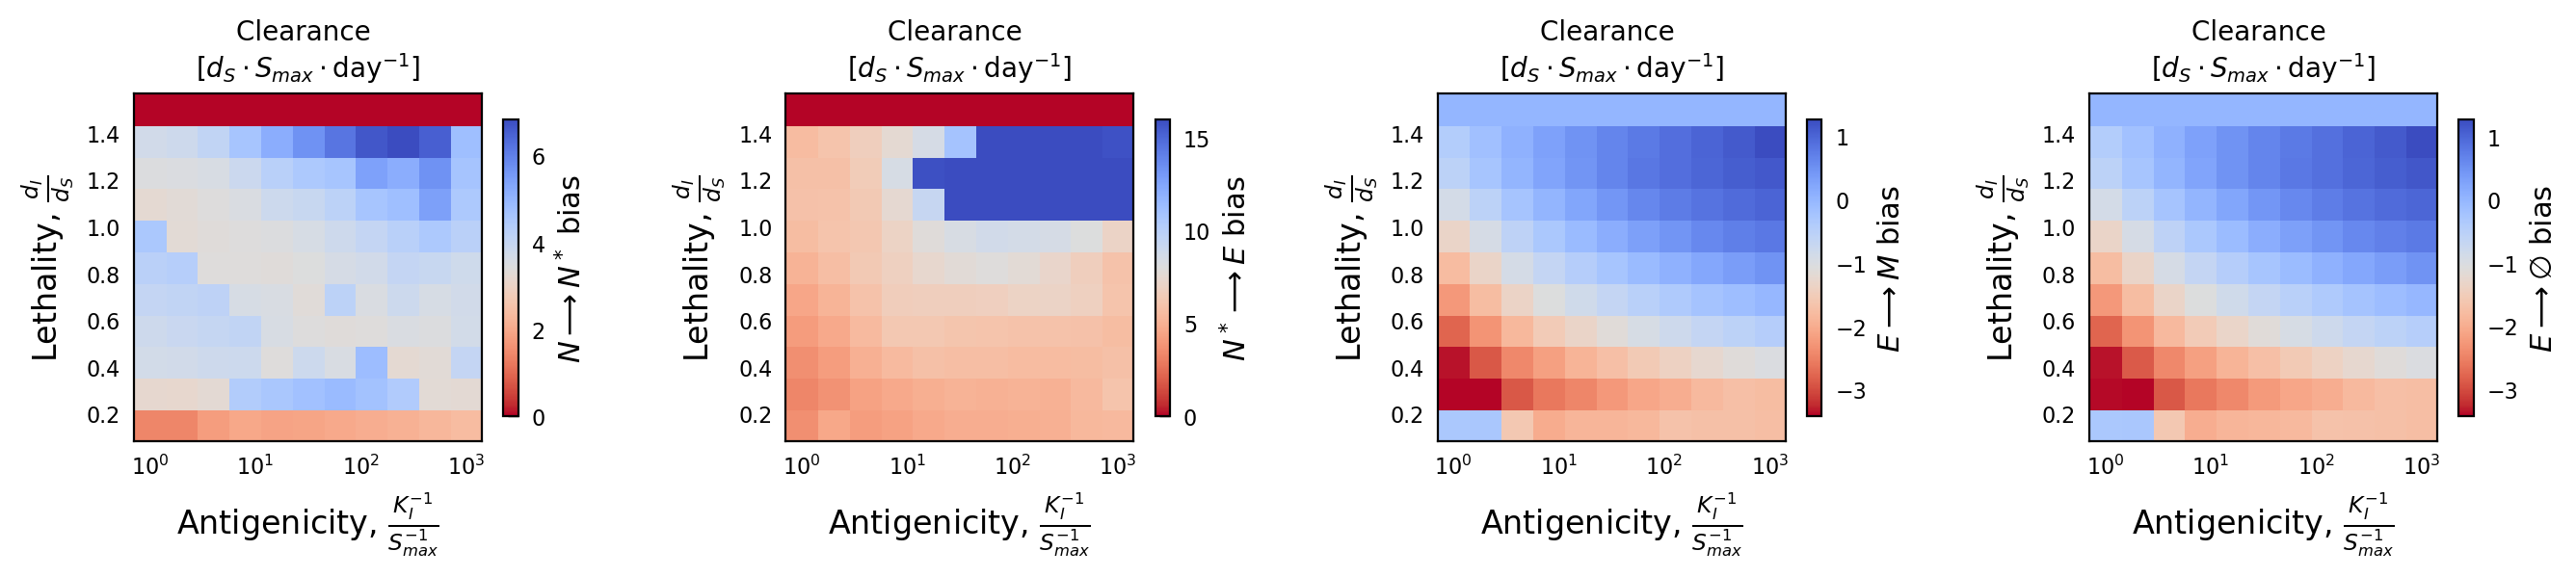

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_0)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

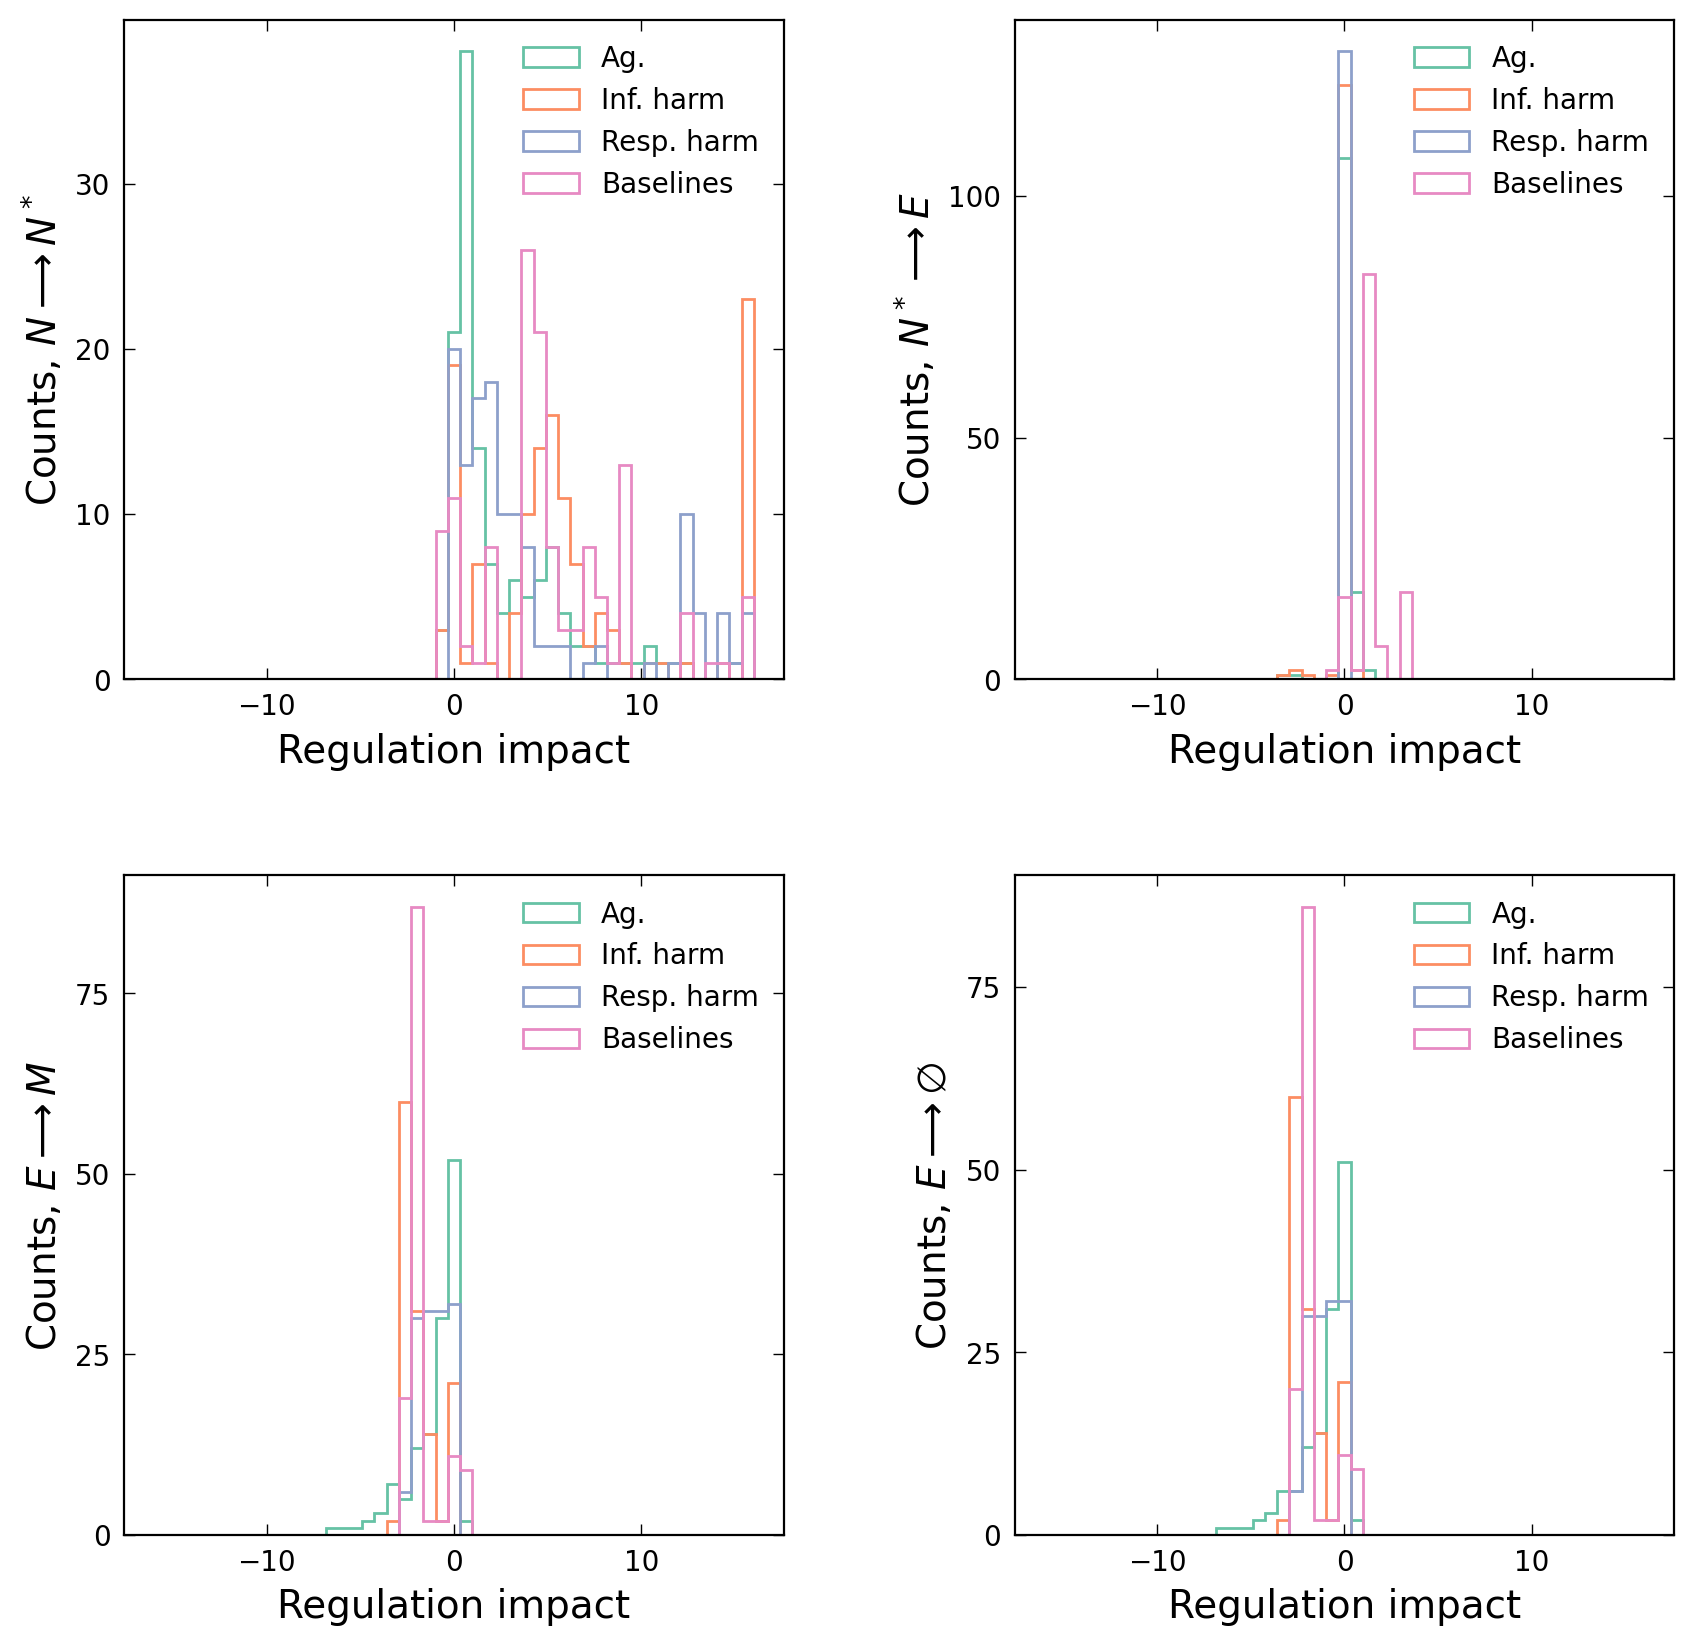

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-4.0*L0_max, 4.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [18]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
727,2.450831e-07,-2.216162,-0.331282,-0.193219,-0.055371,-0.410477,-2.830018,-0.061377,-0.031548,-0.113464,0.342723,0.200079,0.078235,0.428324,0.347458,0.195208,0.074247,0.429010,5.015361,11.129047,4.494822,4.493663,0.001648,0.483402,0.014688,0.013812,0.013085,0.017019,3.347766,0.129793,0.128851,0.073000,0.010826,0.009124,0.007924,0.011427,0.010875,0.009049,0.007872,0.011416,0.233777,6.727881,0.217255,0.217184,0.01,100000.0,0.1,10000.0,10.0,10000000.0,1000000.0,-0.097426,0.0,-2.216162,-0.000011,1.0,0.222382,0.245083,0.0,1.666859,1.184507,0.243569,-6.000001e+00
733,3.121707e-07,-2.379096,-0.393226,-0.206277,-0.075615,-0.347197,-2.967302,0.083359,-0.007128,0.047978,0.357221,0.195840,0.063818,0.353386,0.357160,0.194987,0.059940,0.354046,4.306911,11.049714,4.206337,4.205781,0.002616,0.528917,0.013649,0.011106,0.009757,0.012291,3.581203,0.121186,0.119020,0.060943,0.012652,0.010435,0.009108,0.011852,0.012635,0.010412,0.009076,0.011850,0.226312,7.188558,0.225819,0.225843,0.01,100000.0,0.1,10000.0,100.0,10000000.0,1000000.0,-0.134333,0.0,-2.379096,-0.000192,1.0,0.287375,0.312171,0.0,1.632884,1.163768,0.336879,-6.000001e+00
739,2.712437e-07,-2.256508,-0.354980,-0.180812,-0.065340,-0.346070,0.531946,0.122939,0.017339,-0.084436,0.318346,0.173651,0.074554,0.362763,0.317679,0.174457,0.074479,0.362794,4.263183,11.910772,4.241996,4.242146,0.003824,0.481595,0.011944,0.009860,0.008890,0.011265,71.454704,28.102258,25.305246,15.925713,0.011131,0.009487,0.008661,0.011198,0.011124,0.009497,0.008662,0.011200,0.218655,212.902141,0.218536,0.218541,0.01,100000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,-0.127393,0.0,-2.256508,-0.001934,1.0,0.246657,0.271244,0.0,1.610829,1.147412,0.459287,-6.000001e+00
745,2.206976e-07,-2.124118,-0.138289,-0.302879,-0.074982,-0.448151,-0.021072,-2.127154,0.041806,-0.398897,0.118719,0.271078,0.144571,0.481202,0.116419,0.273653,0.141540,0.480479,5.291572,11.507714,4.652052,4.651691,0.001345,0.459144,0.014834,0.015539,0.014580,0.019624,0.315386,3.306973,0.316468,0.408080,0.007889,0.009251,0.008093,0.011429,0.007884,0.009279,0.008079,0.011428,0.236716,6.958671,0.216805,0.216886,0.01,1000000.0,0.1,10000.0,10.0,10000000.0,1000000.0,-0.086082,0.0,-2.124118,-0.000010,1.0,0.197757,0.220698,0.0,0.754675,1.188807,0.222445,-1.244391e+17
751,3.191768e-07,-2.316057,-0.147147,-0.340744,-0.121683,-0.375971,-0.077886,-2.989613,0.001366,-0.020430,0.136781,0.302626,0.090052,0.384099,0.137284,0.303991,0.089274,0.383889,4.348970,10.894443,4.184053,4.184363,0.002526,0.473484,0.010846,0.012792,0.010641,0.013092,0.105835,3.204175,0.104175,0.052313,0.009648,0.011403,0.009286,0.012018,0.009653,0.011423,0.009281,0.012017,0.212790,6.429884,0.210550,0.210520,0.01,1000000.0,0.1,10000.0,100.0,10000000.0,1000000.0,-0.137313,0.0,-2.316057,-0.000162,1.0,0.292096,0.319177,0.0,0.727266,1.166688,0.325611,-1.244391e+17
757,2.866679e-07,-2.525256,-0.136215,-0.293073,-0.112411,-0.370239,-0.023245,0.045445,0.006257,0.089999,0.125431,0.263882,0.098409,0.379501,0.125159,0.263683,0.098436,0.379511,4.413887,11.440735,4.320349,4.319517,0.017869,0.578821,0.009816,0.011230,0.009647,0.012007,27.686335,36.031757,24.356355,57.464249,0.009047,0.010298,0.008863,0.011392,0.009041,0.010292,0.008859,0.011388,0.237036,673.167722,0.235808,0.235802,0.01,1000000.0,0.1,1